In [25]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares

In [26]:
# cut_up = 18
# cut_down = 3
cut_up = 0
cut_down = 100

In [27]:
def model_line( x:float , m:float , q:float)->float:
    return m*x+q

def import_csv( name:str):
    try:
        data = np.genfromtxt(name, delimiter=",", names=True, dtype=None, encoding=None)
        print("Detected columns:", data.dtype.names)
        print("First rows:")
        for row in data[:5]:
            print(row)
        # example unpack if at least two named columns exist
        
        x = data[data.dtype.names[0]]
        y = data[data.dtype.names[1]]
        sy = data[data.dtype.names[2]]
        print(f"Loaded {x.size} points from columns {data.dtype.names[0]}, {data.dtype.names[1]}")
    except Exception:
        data = np.loadtxt(name, delimiter=",")
        print("Loaded numeric array with shape", data.shape)
        print("First rows:\n", data[:5])
        
        x, y ,sy = data[:, 0], data[:, 1], data[:,2]
        print(f"Using first two columns as x/y with {x.size} points")
    return x, y , sy


In [28]:
def linear_interpolation( x , y , sy)->Minuit:
    ls = LeastSquares(x, y, sy, model_line)
    m = Minuit(ls, m=1, q=1)
    m.migrad()
    m.hesse()
    return m

def mult_lin_int( x , y , sy , points):
    points = np.asarray(points, dtype=int)
    if points.size == 0:
        return []
    if points[0] != 0:
        points = np.concatenate(([0], points))
    if points[-1] != x.size:
        points = np.concatenate((points, [x.size]))
    fits = []
    for i in range(1, len(points)):
        s, e = points[i-1], points[i]
        xs, ys, sys = x[s:e], y[s:e], sy[s:e]
        if xs.size < 2:
            continue
        fits.append(linear_interpolation(xs, ys, sys))
    return fits
    


In [29]:
g_x , g_y , g_sy = import_csv("giunone.csv")
p_x , p_y , p_sy = import_csv("partenope.csv")

Detected columns: ('Tensione', 'Conteggi_medi', 'STD')
First rows:
(800, 141, 8.0)
(810, 145, 9.0)
(807, 145, 12.0)
(812, 152, 7.0)
(817, 154, 13.0)
Loaded 10 points from columns Tensione, Conteggi_medi
Detected columns: ('VOLTAGE', 'MEAN', 'STD')
First rows:
(750, 691.5, 31.84860018)
(730, 406.5, 18.85912688)
(710, 265.0, 8.286535263)
(690, 180.25, 7.088723439)
(685, 184.75, 4.645786622)
Loaded 22 points from columns VOLTAGE, MEAN


# Giunone

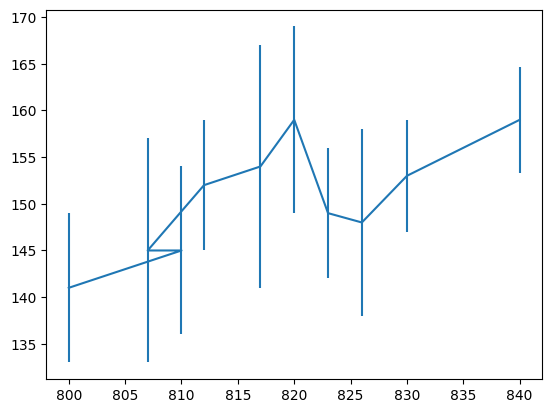

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.794 (χ²/ndof = 0.2)      │              Nfcn = 53               │
│ EDM = 2.81e-18 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ m    │   0.37    │   0.20    │            │            │         │         │       │
│ 1 │ q    │  -0.15e3  │  0.16e3   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────┐
│   │        m        q │
├───┼───────────────────┤
│ m │   0.0399   -32.76 │
│ q │   -32.76 2.69e+04 │
└───┴───────────────────┘

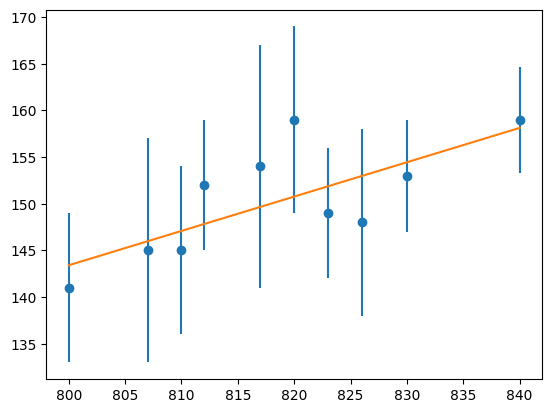

In [30]:

# for i in range(1 , len(points)):
#     cutted_x = x[points[i-1] , points[i]]
#     cutted_y = y[points[i-1] , points[i]]
#     cutted_sy = sy[points[i-1] , points[i]]
#     ls = LeastSquares(cutted_x , cutted_y , cutted_sy , model_line)
#     m = Minuit(ls , m=1 , q = 1)
#     m.migrad()
#     m.hesse()

p_x

plt.errorbar(g_x,g_y,g_sy)
plt.show()
ls = LeastSquares( g_x , g_y , g_sy , model_line)
m = Minuit( ls , m = 1 , q = 1)
m.migrad()
m.hesse()
display(m)

plt.errorbar( x , y , sy , fmt="o")
plot_x = np.linspace( x[0] , x[-1])
plot_y = model_line( plot_x , *m.values)
plt.plot(plot_x , plot_y)
plt.show()

# Partenope

0
5
18


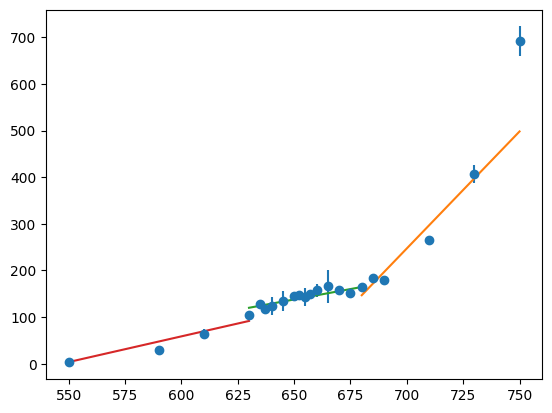

In [ ]:
points_p = [0 , 5 , 18 , len(p_x)]

arr_m = mult_lin_int( p_x , p_y , p_sy , points_p)

plt.errorbar(p_x , p_y , p_sy , fmt="o")
for i , m in enumerate(arr_m):
    print(points_p[i])
    plot_x = np.linspace( min(p_x[points_p[i] : points_p[i+1]+1]) , max(p_x[points_p[i] : points_p[i+1]+1]))
    plot_y = model_line( plot_x , *m.values)
    plt.plot(plot_x , plot_y)
    if i == 1: display(m)
plt.show()
